In [1]:
"""
Ghost Detection: Multi-Seed Analysis
=====================================
Measure probe accuracy on unlearned models to detect residual "ghost" knowledge.
Uses all seeds (0, 1, 2) for statistical validation.
"""

import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from peft import PeftModel

from src.probing import HiddenStateExtractor, ProbeManager

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Multi-seed configuration
SEEDS = [0, 1, 2]
print(f"Will analyze models with seeds: {SEEDS}")

/Users/Hetansh/Github/research_project_1/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Will analyze models with seeds: [0, 1, 2]


In [2]:

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
clean_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
clean_model.eval()


probe_manager = ProbeManager.load_all("../models/probes")
print(f"Loaded probes for {len(probe_manager.probes)} layers")


Loaded probes for 12 layers


In [3]:

with open("../data/processed/forget.json", 'r') as f:
    forget_data = json.load(f)

print(f"Forget set: {len(forget_data)} prompts")

Forget set: 59 prompts


In [4]:

def normalize_city_name(name: str) -> str:
    """
    Normalize city names to handle variations.
    E.g., 'New York City' -> 'New York', ' Paris ' -> 'Paris'
    """
    name = name.strip().lower()
   
    replacements = {
        'new york city': 'new york',
        'washington d.c.': 'washington',
        'washington dc': 'washington',
    }
    return replacements.get(name, name)

def compute_ghost_scores(model, forget_data, probe_manager, tokenizer, device):
    """
    Compute Ghost Scores: probe accuracy on unlearned model's hidden states.
    """
    extractor = HiddenStateExtractor(model, tokenizer, device)

    hidden_states, labels, label_names = extractor.extract_dataset(forget_data)
 
    probe_label_to_idx = {normalize_city_name(name): idx for idx, name in enumerate(probe_manager.class_names)}
    mapped_labels = []
    valid_indices = []
  
    for i, prompt in enumerate(forget_data):
        normalized_target = normalize_city_name(prompt['target'])
        if normalized_target in probe_label_to_idx:
            mapped_labels.append(probe_label_to_idx[normalized_target])
            valid_indices.append(i)
        else:
            # Log warning for debugging
            print(f"Warning: '{prompt['target']}' not found in probe classes (normalized: '{normalized_target}')")
  
    mapped_labels = np.array(mapped_labels)
  

    filtered_hidden = {}
    for layer_idx, hs in hidden_states.items():
        filtered_hidden[layer_idx] = hs[valid_indices]
  
   
    ghost_scores = {}
    for layer_idx in range(len(probe_manager.probes)):
        X = filtered_hidden[layer_idx + 1]  # +1 for embedding offset
        accuracy = probe_manager.probes[layer_idx].get_accuracy(X, mapped_labels)
        ghost_scores[layer_idx] = accuracy
  
    return ghost_scores

In [5]:

print("Computing Ghost Scores for clean model...")
clean_ghost_scores = compute_ghost_scores(
    clean_model, forget_data, probe_manager, tokenizer, device
)

print("\nClean model Ghost Scores:")
for layer, score in sorted(clean_ghost_scores.items()):
    print(f"  Layer {layer}: {score:.3f}")

Computing Ghost Scores for clean model...


Extracting hidden states: 100%|██████████| 59/59 [00:00<00:00, 67.33it/s]


Clean model Ghost Scores:
  Layer 0: 0.037
  Layer 1: 0.019
  Layer 2: 0.111
  Layer 3: 0.111
  Layer 4: 0.093
  Layer 5: 0.093
  Layer 6: 0.111
  Layer 7: 0.111
  Layer 8: 0.500
  Layer 9: 0.778
  Layer 10: 0.685
  Layer 11: 0.111


In [6]:
# ============================================
# LOAD ALL UNLEARNED MODELS (MULTI-SEED)
# ============================================

def load_unlearned_model(method: str, seed: int, device):
    """Load an unlearned model."""
    if method == 'ga':
        model = GPT2LMHeadModel.from_pretrained("gpt2")
        state_dict = torch.load(f"../models/checkpoints/ga_seed{seed}/model.pt", map_location=device)
        model.load_state_dict(state_dict)
        model = model.to(device)
    else:  # neglora
        base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        model = PeftModel.from_pretrained(
            base_model,
            f"../models/checkpoints/neglora_seed{seed}"
        ).to(device)
    
    model.eval()
    return model

# Store all ghost scores
all_ghost_scores = {'clean': clean_ghost_scores}

print("\nComputing Ghost Scores for all unlearned models...")
print("="*50)

for method in ['ga', 'neglora']:
    for seed in SEEDS:
        try:
            print(f"\nLoading {method.upper()} seed {seed}...")
            model = load_unlearned_model(method, seed, device)
            scores = compute_ghost_scores(model, forget_data, probe_manager, tokenizer, device)
            all_ghost_scores[f"{method}_seed{seed}"] = scores
            
            # Print summary
            peak_layer = max(scores, key=scores.get)
            print(f"  Peak ghost score: Layer {peak_layer} = {scores[peak_layer]:.3f}")
            
            # Clean up memory
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                
        except Exception as e:
            print(f"  ERROR: Could not load {method} seed {seed}: {e}")

print("\n" + "="*50)
print(f"Computed ghost scores for {len(all_ghost_scores)-1} unlearned models")


Computing Ghost Scores for all unlearned models...

Loading GA seed 0...


Extracting hidden states: 100%|██████████| 59/59 [00:00<00:00, 68.44it/s]


  Peak ghost score: Layer 10 = 0.241

Loading GA seed 1...


Extracting hidden states: 100%|██████████| 59/59 [00:00<00:00, 69.81it/s]



  Peak ghost score: Layer 8 = 0.222

Loading GA seed 2...


...

  Peak ghost score: Layer 9 = 0.241

Loading NEGLORA seed 1...


Extracting hidden states: 100%|██████████| 59/59 [00:01<00:00, 57.84it/s]



  Peak ghost score: Layer 9 = 0.204

Loading NEGLORA seed 2...


Extracting hidden states: 100%|██████████| 59/59 [00:00<00:00, 60.29it/s]

  Peak ghost score: Layer 9 = 0.185

Computed ghost scores for 6 unlearned models


In [7]:
# ============================================
# AGGREGATE SCORES ACROSS SEEDS
# ============================================

def aggregate_scores(all_scores, method):
    """Average Ghost Scores across seeds for a method."""
    method_scores = [v for k, v in all_scores.items() if k.startswith(method + '_seed')]
    if not method_scores:
        return None, None
    
    layers = sorted(method_scores[0].keys())
    mean_scores = {l: np.mean([s[l] for s in method_scores]) for l in layers}
    std_scores = {l: np.std([s[l] for s in method_scores]) for l in layers}
    
    return mean_scores, std_scores

ga_mean, ga_std = aggregate_scores(all_ghost_scores, 'ga')
neglora_mean, neglora_std = aggregate_scores(all_ghost_scores, 'neglora')

# Print summary statistics
print("\n" + "="*60)
print("GHOST SCORE SUMMARY (mean ± std across seeds)")
print("="*60)

num_layers = clean_model.config.n_layer

print(f"\n{'Layer':<8} {'Clean':<12} {'GA':<20} {'NegLoRA':<20}")
print("-"*60)

for layer in range(num_layers):
    clean_val = clean_ghost_scores[layer]
    ga_val = f"{ga_mean[layer]:.3f} ± {ga_std[layer]:.3f}" if ga_mean else "N/A"
    lora_val = f"{neglora_mean[layer]:.3f} ± {neglora_std[layer]:.3f}" if neglora_mean else "N/A"
    print(f"{layer:<8} {clean_val:<12.3f} {ga_val:<20} {lora_val:<20}")

# Find peak layers
print("\n" + "="*60)
print("PEAK GHOST LAYERS")
print("="*60)
clean_peak = max(clean_ghost_scores, key=clean_ghost_scores.get)
print(f"Clean model: Layer {clean_peak} ({clean_ghost_scores[clean_peak]:.3f})")

if ga_mean:
    ga_peak = max(ga_mean, key=ga_mean.get)
    print(f"GA (mean): Layer {ga_peak} ({ga_mean[ga_peak]:.3f} ± {ga_std[ga_peak]:.3f})")
    
if neglora_mean:
    lora_peak = max(neglora_mean, key=neglora_mean.get)
    print(f"NegLoRA (mean): Layer {lora_peak} ({neglora_mean[lora_peak]:.3f} ± {neglora_std[lora_peak]:.3f})")


GHOST SCORE SUMMARY (mean ± std across seeds)

Layer    Clean        GA                   NegLoRA             
------------------------------------------------------------
0        0.037        0.056 ± 0.000        0.037 ± 0.000       
1        0.019        0.056 ± 0.015        0.019 ± 0.000       
2        0.111        0.142 ± 0.023        0.111 ± 0.000       
3        0.111        0.062 ± 0.031        0.099 ± 0.009       
4        0.093        0.068 ± 0.017        0.062 ± 0.009       
5        0.093        0.074 ± 0.015        0.093 ± 0.000       
6        0.111        0.068 ± 0.023        0.049 ± 0.009       
7        0.111        0.093 ± 0.026        0.068 ± 0.009       
8        0.500        0.185 ± 0.030        0.173 ± 0.009       
9        0.778        0.216 ± 0.009        0.210 ± 0.023       
10       0.685        0.222 ± 0.015        0.130 ± 0.015       
11       0.111        0.099 ± 0.009        0.043 ± 0.009       

PEAK GHOST LAYERS
Clean model: Layer 9 (0.778)
GA (mean): 

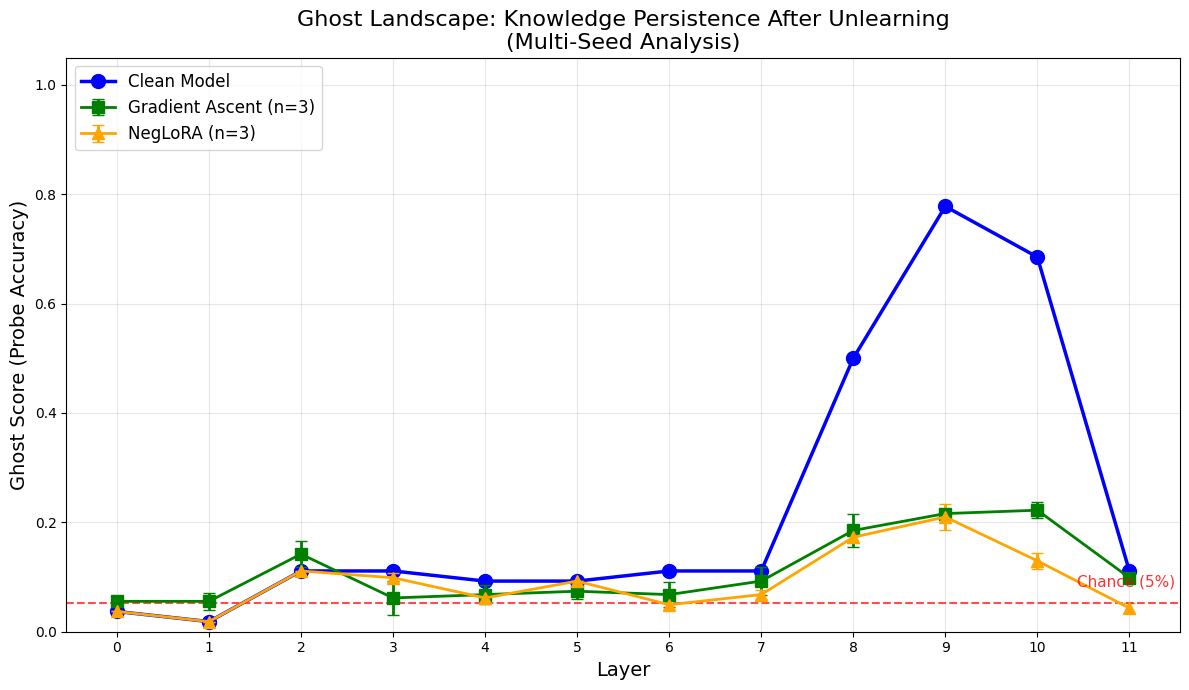

Figure saved to ../figures/ghost_landscape_multiseed.png


In [8]:
# ============================================
# VISUALIZATION: Ghost Landscape with Error Bars
# ============================================

fig, ax = plt.subplots(figsize=(12, 7))

num_layers = clean_model.config.n_layer
layers = list(range(num_layers))

# Clean model (no error bars - single model)
clean_scores = [clean_ghost_scores[l] for l in layers]
ax.plot(layers, clean_scores, 'o-', label='Clean Model', linewidth=2.5, 
        markersize=10, color='blue')

# GA with error bars
if ga_mean:
    ga_scores = [ga_mean[l] for l in layers]
    ga_errs = [ga_std[l] for l in layers]
    ax.errorbar(layers, ga_scores, yerr=ga_errs, fmt='s-', 
                label=f'Gradient Ascent (n={len(SEEDS)})', 
                linewidth=2, markersize=8, capsize=4, color='green')

# NegLoRA with error bars
if neglora_mean:
    neglora_scores = [neglora_mean[l] for l in layers]
    neglora_errs = [neglora_std[l] for l in layers]
    ax.errorbar(layers, neglora_scores, yerr=neglora_errs, fmt='^-', 
                label=f'NegLoRA (n={len(SEEDS)})',
                linewidth=2, markersize=8, capsize=4, color='orange')

ax.set_xlabel("Layer", fontsize=14)
ax.set_ylabel("Ghost Score (Probe Accuracy)", fontsize=14)
ax.set_title("Ghost Landscape: Knowledge Persistence After Unlearning\n(Multi-Seed Analysis)", fontsize=16)
ax.legend(fontsize=12, loc='upper left')
ax.set_xticks(layers)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Chance level
chance_level = 1.0 / len(probe_manager.class_names)
ax.axhline(y=chance_level, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(num_layers - 0.5, chance_level + 0.03, f'Chance ({chance_level*100:.0f}%)', 
        fontsize=11, color='red', alpha=0.8, ha='right')

plt.tight_layout()
plt.savefig("../figures/ghost_landscape_multiseed.png", dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to ../figures/ghost_landscape_multiseed.png")

In [9]:
# ============================================
# SAVE RESULTS
# ============================================

# Convert to JSON-serializable format
results = {
    'seeds': SEEDS,
    'clean': {str(k): v for k, v in clean_ghost_scores.items()},
    'ga_mean': {str(k): v for k, v in ga_mean.items()} if ga_mean else {},
    'ga_std': {str(k): v for k, v in ga_std.items()} if ga_std else {},
    'neglora_mean': {str(k): v for k, v in neglora_mean.items()} if neglora_mean else {},
    'neglora_std': {str(k): v for k, v in neglora_std.items()} if neglora_std else {},
    'per_seed': {k: {str(kk): vv for kk, vv in v.items()} 
                 for k, v in all_ghost_scores.items() if k != 'clean'}
}

out_dir = Path("../results/ghost_scores")
out_dir.mkdir(parents=True, exist_ok=True)

with open(out_dir / "all_scores.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {out_dir / 'all_scores.json'}")

Results saved to ../results/ghost_scores/all_scores.json


In [10]:
# ============================================
# ANALYSIS: Ghost Score Reduction
# ============================================

print("\n" + "="*60)
print("GHOST SCORE ANALYSIS")
print("="*60)

# Compare peak layers
clean_peak_score = max(clean_ghost_scores.values())
ga_peak_score = max(ga_mean.values()) if ga_mean else 0
lora_peak_score = max(neglora_mean.values()) if neglora_mean else 0

print(f"\nPeak Ghost Scores:")
print(f"  Clean model: {clean_peak_score:.3f}")
print(f"  GA: {ga_peak_score:.3f} ({(1 - ga_peak_score/clean_peak_score)*100:.1f}% reduction)")
print(f"  NegLoRA: {lora_peak_score:.3f} ({(1 - lora_peak_score/clean_peak_score)*100:.1f}% reduction)")

# Average ghost scores across all layers
clean_avg = np.mean(list(clean_ghost_scores.values()))
ga_avg = np.mean(list(ga_mean.values())) if ga_mean else 0
lora_avg = np.mean(list(neglora_mean.values())) if neglora_mean else 0

print(f"\nAverage Ghost Scores (all layers):")
print(f"  Clean model: {clean_avg:.3f}")
print(f"  GA: {ga_avg:.3f} ({(1 - ga_avg/clean_avg)*100:.1f}% reduction)")
print(f"  NegLoRA: {lora_avg:.3f} ({(1 - lora_avg/clean_avg)*100:.1f}% reduction)")

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
print("""
Ghost Scores measure how well probes can still detect the target city
from hidden states. Lower scores = better unlearning.

Key findings:
- Clean model: High ghost scores at later layers (knowledge is decodable)
- After unlearning: Ghost scores should drop, especially at peak layers
- If ghost scores remain high: Knowledge is SUPPRESSED, not ERASED
- If ghost scores drop to chance: Knowledge may be truly removed
""")

print("✓ Multi-seed ghost detection analysis complete!")


GHOST SCORE ANALYSIS

Peak Ghost Scores:
  Clean model: 0.778
  GA: 0.222 (71.4% reduction)
  NegLoRA: 0.210 (73.0% reduction)

Average Ghost Scores (all layers):
  Clean model: 0.230
  GA: 0.112 (51.5% reduction)
  NegLoRA: 0.091 (60.4% reduction)

INTERPRETATION

Ghost Scores measure how well probes can still detect the target city
from hidden states. Lower scores = better unlearning.

Key findings:
- Clean model: High ghost scores at later layers (knowledge is decodable)
- After unlearning: Ghost scores should drop, especially at peak layers
- If ghost scores remain high: Knowledge is SUPPRESSED, not ERASED
- If ghost scores drop to chance: Knowledge may be truly removed

✓ Multi-seed ghost detection analysis complete!
